# mRMR (maximal relevance minimal redundancy) for neuronal morphology analysis

## Roadmap

**Scientific question**  
↓  
**SWC: how a neuron is stored**  
↓  
**Vaa3D: SWC → 22 morphology features**  
↓  
**How can we select a small, non-repetitive subset?**  
↓  
**mRMR: relevance + redundancy**  
↓  
**Use mutual information (MI) to quantify both**  
↓  
**Count-based MI requires discretizing continuous features**  
↓  
**Calculate one MI example → relevance ranking**  
↓  
**See why relevance-only selection repeats information**  
↓  
**Calculate redundancy → MID**  
↓  
**Selected features → t-SNE + classifier**  
↓  
**Extension 1: discretization sensitivity**  
↓  
**Extension 2: libraries implement the mRMR framework differently**

## 1. Scientific question

> Which compact, complementary set of dendritic morphology features best
> distinguishes neurons from different brain regions?

The default analysis uses all three broad regions. A single configuration list
near the top can still switch the notebook to any two of them.

## 2. SWC: how a neuron is stored

An **SWC** file stores a neuronal tree as nodes and parent–child links. Here we
retain soma (type 1) plus basal/apical dendrites (types 3/4), remove axon
(type 2), and resample each dendritic tree at 2 µm with Vaa3D.

### One row is one node

An SWC file is a table plus a tree rule. Each row defines one node; the last
column points to its parent. Children are not stored in a separate column:
the children of node `2` are all rows whose `parent_id` equals `2`.

```text
node 1: soma/root (parent = -1)
├── node 2: basal dendrite (parent = 1)
│   ├── node 3: basal dendrite (parent = 2)
│   └── node 4: basal dendrite (parent = 2)
└── node 5: axon (parent = 1)
    └── node 6: axon (parent = 5)
```

The standard seven columns are:

| Column | Name | Meaning | Example |
|---:|---|---|---:|
| 1 | `node_id` | Unique integer node identifier | `3` |
| 2 | `type` | Compartment code: 1 soma, 2 axon, 3 basal dendrite, 4 apical dendrite | `3` |
| 3 | `x` | X coordinate | `-3.0` |
| 4 | `y` | Y coordinate | `9.0` |
| 5 | `z` | Z coordinate | `0.0` |
| 6 | `radius` | Local neurite radius | `0.8` |
| 7 | `parent_id` | Parent node ID; `-1` marks a root | `2` |

For example, row `3 3 -3 9 0 0.8 2` means: node 3 is a basal
dendrite point at $(-3,9,0)$ with radius 0.8, connected to parent node 2.
Coordinates and radius follow the file's declared data units; this subset uses
micrometers.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.plotting import REGION_COLORS, plot_top_relevance
from src.swc import plot_swc_2d, read_swc

# Choose any two regions, or all three. 
TARGET_REGIONS = ["Cortex", "Thalamus", "CP"]
# Example two-class alternative: ["CP", "Thalamus"]
N_SELECTED = 8

if len(TARGET_REGIONS) not in (2, 3) or len(set(TARGET_REGIONS)) != len(TARGET_REGIONS):
    raise ValueError("TARGET_REGIONS must contain two or three distinct regions")

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 30)
pd.set_option("display.precision", 3)

### A toy dataset consisting of dendritic morphological reconstructions from
### **three brain regions (Cortex, Thalamus, Caudate Putamen)**
### Each with **100** randomly sampled neurons in SWC format.



In [29]:
df_metadata = pd.read_csv(ROOT / "data" / "metadata.csv")
df_metadata.groupby(["broad_region"]).size().to_frame("neurons")

,neurons
broad_region,
CP,100
Cortex,100
Thalamus,100


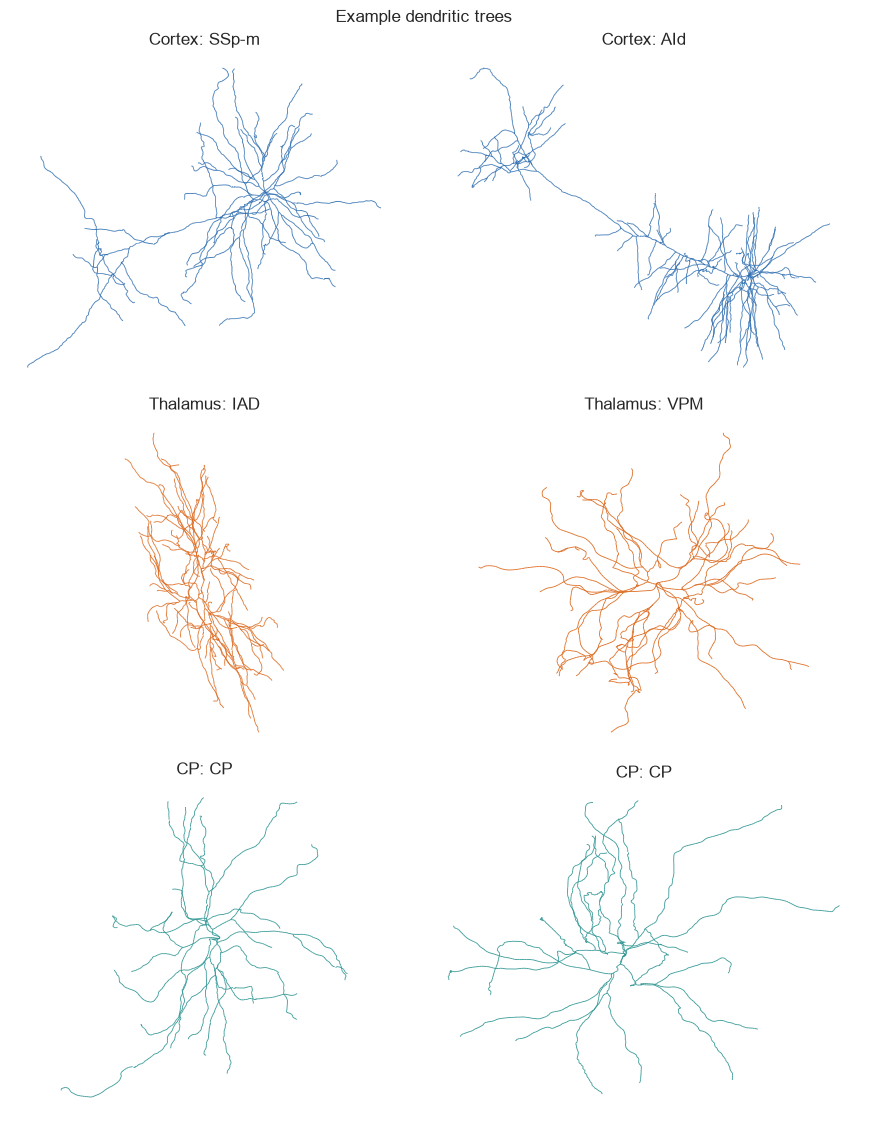

In [3]:
examples = pd.concat([
    df_metadata[df_metadata["broad_region"] == region].head(2)
    for region in TARGET_REGIONS
])

figure, axes = plt.subplots(
    len(TARGET_REGIONS), 2, figsize=(9, 3.8 * len(TARGET_REGIONS)), squeeze=False
)
for ax, row in zip(axes.flat, examples.itertuples(index=False)):
    nodes = read_swc(ROOT / "data" / "subset_dendrite_resampled_2um" / row.swc_file)
    plot_swc_2d(
        nodes,
        ax=ax,
        color=REGION_COLORS[row.broad_region],
        title=f"{row.broad_region}: {row.soma_region}",
    )
figure.suptitle("Example dendritic trees")
figure.tight_layout()

## 3. Vaa3D: from SWC files to morphology features

Vaa3D-x provides Windows, Linux, and macOS release assets on the
[Vaa3D-x 1.1.4 release page](https://github.com/Vaa3D/release/releases/tag/v1.1.4).
Feature extraction is a preparation step.

The repository's preparation workflow is:

1. **Keep the dendritic compartment.** For the dendrite analysis, retain SWC
   types 1, 3, and 4 and remove type 2. See `scripts/prepare_compartments.py`.
2. **Resample the node interval at 2 µm** with the `resample_swc` plugin:

   ```text
   vaa3d -x resample_swc -f resample_swc \
         -i input_dendrite.swc -o input_dendrite_2um.swc -p 2
   ```

3. **Calculate the 22 global morphology features** with
   `global_neuron_feature`:

   ```text
   vaa3d -x global_neuron_feature -f compute_feature \
         -i input_dendrite_2um.swc
   ```

On Windows, Vaa3D commonly uses `/x /f /i /o /p`; Linux and macOS use
`-x -f -i -o -p`. The Python wrappers detect the platform and construct the
correct argument list. 

## 4. The 22-feature morphology table

Vaa3D's `global_neuron_feature` plugin computed 22 [L-Measure](http://cng.gmu.edu:8080/Lm/)-style global
morphological descriptors from each dendritic tree.\
They cover size, extent, branching, geometry, and spatial organization.


In [31]:
df_morphology = pd.read_csv(ROOT / "data" / "morphology_features.csv")
table = df_metadata.merge(df_morphology, on="swc_file", validate="one_to_one")
feature_names = [name for name in df_morphology.columns if name != "swc_file"]

main = table[table["broad_region"].isin(TARGET_REGIONS)].copy()
X = main[feature_names].replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median()).reset_index(drop=True)
y = main["broad_region"].reset_index(drop=True)

print(f"neurons: {len(X)} ({y.value_counts().to_dict()})")
print(f"dendritic morphology features: {len(feature_names)}")
table[["neuron_id", "broad_region", *feature_names]].head()

neurons: 300 ({'Cortex': 100, 'Thalamus': 100, 'CP': 100})
dendritic morphology features: 22


,neuron_id,broad_region,number_of_nodes,soma_surface,number_of_stems,number_of_bifurcations,number_of_branches,number_of_tips,overall_width,overall_height,...,total_volume,max_euclidean_distance,max_path_distance,max_branch_order,average_contraction,average_fragmentation,average_parent_daughter_ratio,average_bifurcation_angle_local,average_bifurcation_angle_remote,hausdorff_dimension
0,18869_3321_x21485_y7678,Cortex,4783.0,12.566,6.0,46.0,96.0,51.0,672.79,570.03,...,29457.1,681.966,904.719,19.0,0.911,48.812,1.0,69.962,68.753,1.142
1,182724_2525_x8483_y21088,Cortex,5932.0,12.566,11.0,89.0,187.0,99.0,720.42,579.72,...,36392.3,679.575,926.858,36.0,0.934,30.717,1.0,76.754,66.242,1.227
2,18453_3186_x12745_y7108,Cortex,3783.0,12.566,6.0,76.0,156.0,81.0,378.38,331.92,...,22983.5,315.014,402.342,13.0,0.925,23.244,1.0,66.226,56.333,1.124
3,18867_2903_x13633_y8787,Cortex,10868.0,12.566,13.0,147.0,305.0,159.0,871.73,1040.67,...,66315.5,991.481,1556.470,37.0,0.908,34.630,1.0,78.828,71.354,1.233
4,191812_5158_x9017_y25877,Cortex,5411.0,12.566,10.0,70.0,148.0,79.0,376.73,469.73,...,33371.0,579.079,686.899,10.0,0.925,35.554,1.0,64.405,60.143,1.255


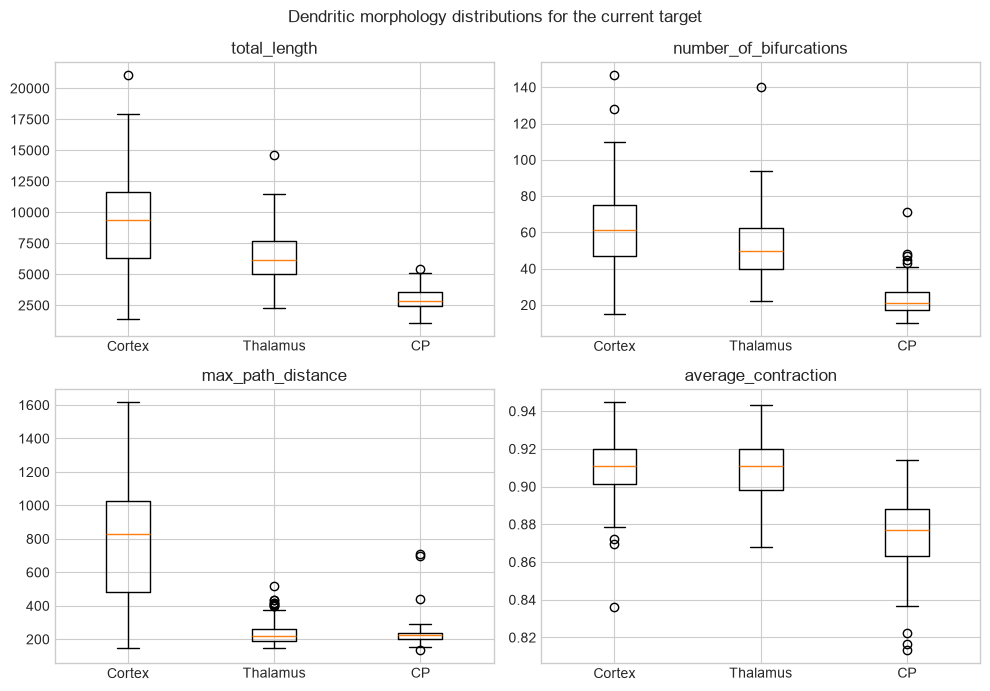

In [5]:
overview_features = [
    "total_length",
    "number_of_bifurcations",
    "max_path_distance",
    "average_contraction",  # straightness
]
figure, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, feature in zip(axes.flat, overview_features):
    values = [X.loc[y == region, feature] for region in TARGET_REGIONS]
    ax.boxplot(values, tick_labels=TARGET_REGIONS)
    ax.set_title(feature)
figure.suptitle("Dendritic morphology distributions for the current target")
figure.tight_layout()

## 5. From 22 features to a compact, non-repetitive set

The central idea of mRMR is **maximum relevance and minimum redundancy**:

- a selected feature should contain information about the target class;
- two selected features should not contain too much of the same information.

This directly answers our selection question: reward class information, but
penalize repeated morphology.

## 6. Use mutual information for relevance and redundancy

Following the original paper, we use **mutual information (MI)** for both parts:
$I(x_i;c)$ estimates feature–class relevance, while $I(x_i;x_j)$ estimates
feature–feature redundancy.

The count-based MI formula operates on discrete states. Our morphology
features are continuous, so the first step is discretization. The original
mRMR software recommends three states using thresholds at
$\mu-\alpha\sigma$ and $\mu+\alpha\sigma$; here $\alpha=1$:

$$
x^{(d)}=\begin{cases}
-1 & x < \mu-\sigma\\
0 & \mu-\sigma \le x \le \mu+\sigma\\
+1 & x > \mu+\sigma.
\end{cases}
$$


In [6]:
def discretize_mean_sd(features: pd.DataFrame, alpha=1.0) -> pd.DataFrame:
    '''Map each continuous feature to low (-1), middle (0), or high (+1).'''
    discrete = pd.DataFrame(index=features.index)

    for name in features:
        values = features[name].to_numpy(dtype=float)
        mean = values.mean()
        sd = values.std(ddof=0)

        states = np.zeros(len(values), dtype=np.int8)
        states[values < mean - alpha * sd] = -1
        states[values > mean + alpha * sd] = 1
        discrete[name] = states

    return discrete


X_discrete = discretize_mean_sd(X)

state_counts = X_discrete["total_length"].value_counts().sort_index()
state_counts.rename("neurons").to_frame().rename_axis("discrete value")

,neurons
discrete value,
-1,36
0,214
1,50


### A six-neuron MI example

Suppose six neurons have one morphology feature, `average_contraction (average branch straightness)`, and a
region label $Y$. The mean is 0.89 and the population SD is approximately
0.034, giving cut points of 0.856 and 0.924.

| Neuron | Region $Y$ | Raw feature | Discrete $X$ |
|---|---|---:|---|
| N1 | CP | 0.84 | low (-1) |
| N2 | CP | 0.86 | middle (0) |
| N3 | CP | 0.88 | middle (0) |
| N4 | Thalamus | 0.90 | middle (0) |
| N5 | Thalamus | 0.92 | middle (0) |
| N6 | Thalamus | 0.94 | high (+1) |

First count $X$ and $Y$ separately:

| $X$ state | Count | $p(X)$ | | $Y$ class | Count | $p(Y)$ |
|---|---:|---:|---|---|---:|---:|
| low | 1 | $1/6$ | | CP | 3 | $3/6$ |
| middle | 4 | $4/6$ | | Thalamus | 3 | $3/6$ |
| high | 1 | $1/6$ | | | | |

Then count the joint states:

| $X$ state | CP count | Thalamus count | Nonzero $p(X,Y)$ |
|---|---:|---:|---|
| low | 1 | 0 | $p(\mathrm{low},\mathrm{CP})=1/6$ |
| middle | 2 | 2 | $p(\mathrm{middle},\mathrm{CP})=2/6$; $p(\mathrm{middle},\mathrm{Thalamus})=2/6$ |
| high | 0 | 1 | $p(\mathrm{high},\mathrm{Thalamus})=1/6$ |

Now substitute the nonzero joint states into

$$I(X;Y)=\sum_{x,y}p(x,y)\log\frac{p(x,y)}{p(x)p(y)}.$$

$$
\begin{aligned}
I(X;Y)={}&\frac16\log\frac{1/6}{(1/6)(3/6)}
+\frac26\log\frac{2/6}{(4/6)(3/6)}\\
&+\frac26\log\frac{2/6}{(4/6)(3/6)}
+\frac16\log\frac{1/6}{(1/6)(3/6)}\\
={}&\frac13\log 2 \approx 0.231.
\end{aligned}
$$


In [7]:
def count_based_mi(x, y):
    '''Calculate I(X;Y) directly from a joint count table.'''
    joint_counts = pd.crosstab(
        pd.Series(np.asarray(x), name="X"),
        pd.Series(np.asarray(y), name="Y"),
    )
    p_xy = joint_counts.to_numpy(dtype=float) / joint_counts.to_numpy().sum()
    p_x = p_xy.sum(axis=1, keepdims=True)
    p_y = p_xy.sum(axis=0, keepdims=True)

    occupied = p_xy > 0  # zero-probability states contribute zero
    MI = np.sum(p_xy[occupied] * np.log(p_xy[occupied] / (p_x * p_y)[occupied]))

    # # same as the "for loop"
    # MI = 0.0
    # for i in range(p_xy.shape[0]):
    #     for j in range(p_xy.shape[1]):
    #         if p_xy[i, j] > 0:
    #             MI += p_xy[i, j] * np.log(p_xy[i, j] / (p_x[i, 0] * p_y[0, j]))

    return float(MI)


toy_x = [-1, 0, 0, 0, 0, 1]  # already discretized
toy_y = ["CP", "CP", "CP", "Thalamus", "Thalamus", "Thalamus"]
print(f"example MI: {count_based_mi(toy_x, toy_y):.3f}")

example MI: 0.231


In [8]:
def relevance_scores(discrete: pd.DataFrame, target: pd.Series) -> pd.Series:
    '''Rank features by I(feature; class).'''
    scores = {
        name: count_based_mi(discrete[name], target)
        for name in discrete
    }
    return pd.Series(scores, name="relevance").sort_values(ascending=False)


mi_relevance = relevance_scores(X_discrete, y)
mi_relevance.head(8).to_frame()

,relevance
number_of_branches,0.261
number_of_tips,0.256
number_of_bifurcations,0.249
max_path_distance,0.236
max_branch_order,0.219
overall_height,0.205
max_euclidean_distance,0.203
overall_depth,0.198


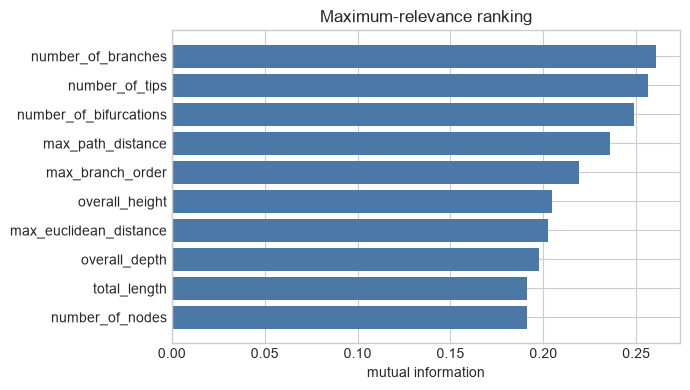

In [9]:
plot_top_relevance(mi_relevance, n=10)
plt.tight_layout()

## 7. Why relevance alone is insufficient

> Highly predictive features may be describing the similar morphology.

The global feature set already contains related measurements. e.g., number of branches, tips, and bifurcation points often co-vary. Selecting only
by $I(x;c)$ (relevance) can be redundant on the same biological dimension.

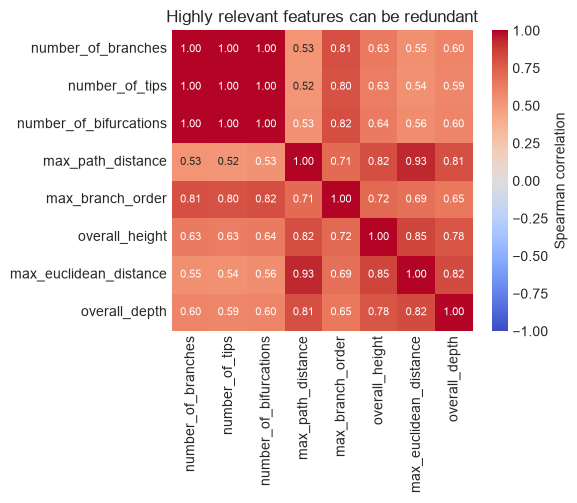

In [10]:
highly_relevant = mi_relevance.head(8).index.tolist()
plt.figure(figsize=(6, 5))
sns.heatmap(
    X[highly_relevant].corr(method="spearman"),
    vmin=-1, vmax=1, center=0, cmap="coolwarm", square=True,
    cbar_kws={"label": "Spearman correlation"},
    annot=True, fmt=".2f", annot_kws={"fontsize": 8}
)
plt.title("Highly relevant features can be redundant")
plt.tight_layout()

## 8. Calculate redundancy and build MID score

The MID objective is **relevance minus redundancy**, $D-R$. Its Eq. (7) chooses the next feature
$x_j$ by maximizing

$$\operatorname{score}(x_j)=I(x_j;c)-\frac{1}{|S|}\sum_{x_i\in S}I(x_j;x_i).$$
$S$ is the set of already selected features. $|S|$ is the number of already selected features.


In [11]:
first_feature = mi_relevance.index[0]
redundancy_to_first = pd.Series({
    name: count_based_mi(X_discrete[name], X_discrete[first_feature])
    for name in mi_relevance.index[1:9]
}, name=f"I(feature; {first_feature})")
redundancy_to_first.sort_values(ascending=False).to_frame()

,I(feature; number_of_branches)
number_of_tips,0.902
number_of_bifurcations,0.736
number_of_nodes,0.327
max_branch_order,0.147
overall_depth,0.101
max_path_distance,0.087
overall_height,0.064
max_euclidean_distance,0.060


Now translate the incremental MID equation directly into a loop. At each step
we calculate every candidate's relevance, its mean redundancy with the already
selected features, and their difference.

In [12]:
def my_mRMR(discrete, target, k):
    '''
    MID using the MI function shown above.
    '''
    
    relevance = relevance_scores(discrete, target)  # relevance of all features against the class label
    selected = []  # selected features
    trace = []

    # skip the first feature, which is the most relevant, should be selected first
    for step in range(1, k + 1):
        candidates = [name for name in discrete if name not in selected]
        step_rows = []

        # calculate redundancy for each candidate feature with respect to the already selected features
        for candidate in candidates:
            pairwise_mi = [
                count_based_mi(discrete[candidate], discrete[chosen])
                for chosen in selected
            ]
            redundancy = np.mean(pairwise_mi) if pairwise_mi else 0.0  # average redundancy with already selected features
            step_rows.append({
                "step": step,
                "candidate": candidate,
                "relevance": relevance[candidate],
                "redundancy": redundancy,
                "mrmr_score": relevance[candidate] - redundancy,
            })

        winner = max(step_rows, key=lambda row: row["mrmr_score"])["candidate"]
        selected.append(winner)
        for row in step_rows:
            row["selected_next"] = row["candidate"] == winner
        trace.extend(step_rows)

    return selected, pd.DataFrame(trace)


mrmr_order, mrmr_trace = my_mRMR(X_discrete, y, k=len(feature_names))
selected_features = mrmr_order[:N_SELECTED]
pd.DataFrame({"selection_order": range(1, N_SELECTED + 1),
              "selected_feature": selected_features})

,selection_order,selected_feature
0,1,number_of_branches
1,2,max_path_distance
2,3,average_bifurcation_angle_remote
3,4,overall_height
4,5,average_contraction
5,6,overall_depth
6,7,number_of_stems
7,8,number_of_bifurcations


#### Looking back -- How first three features were selected?

In [13]:
# First feature we only care about its relevance.
mrmr_trace[mrmr_trace["step"]==1].sort_values("mrmr_score", ascending=False).head()

,step,candidate,relevance,redundancy,mrmr_score,selected_next
4,1,number_of_branches,0.261,0.0,0.261,True
5,1,number_of_tips,0.256,0.0,0.256,False
3,1,number_of_bifurcations,0.249,0.0,0.249,False
14,1,max_path_distance,0.236,0.0,0.236,False
15,1,max_branch_order,0.219,0.0,0.219,False


In [14]:
# Inspect why the second feature wins.
# selected features now contain ["number_of_branches"]
mrmr_trace[mrmr_trace["step"]==2].sort_values("mrmr_score", ascending=False).head()

,step,candidate,relevance,redundancy,mrmr_score,selected_next
35,2,max_path_distance,0.236,0.087,0.149,True
41,2,average_bifurcation_angle_remote,0.189,0.044,0.145,False
34,2,max_euclidean_distance,0.203,0.060,0.143,False
28,2,overall_height,0.205,0.064,0.140,False
29,2,overall_depth,0.198,0.101,0.097,False


In [15]:
# Inspect why the third feature wins.
# selected features now contain ["number_of_branches", "max_path_distance"]
mrmr_trace[mrmr_trace["step"]==3].sort_values("mrmr_score", ascending=False).head()

,step,candidate,relevance,redundancy,mrmr_score,selected_next
61,3,average_bifurcation_angle_remote,0.189,0.041,0.149,True
57,3,average_contraction,0.162,0.058,0.104,False
49,3,overall_height,0.205,0.143,0.061,False
45,3,number_of_stems,0.107,0.055,0.052,False
60,3,average_bifurcation_angle_local,0.074,0.054,0.021,False


### Implementation check with `pymrmr`

Compare our `my_mRMR` against
[`pymrmr`](https://pypi.org/project/pymrmr/), which wraps the original discrete mRMR program.
```python
import pymrmr  # usage: selected = pymrmr.mRMR(df, "MID", K)
```

In [16]:
from src.mrmr import select_features

pymrmr_selected = select_features(
    X, y, N_SELECTED, method="pymrmr", binning="mean_std_3", alpha=1.0
)
implementation_check = pd.DataFrame({
    "my_mRMR": selected_features,
    "pymrmr": pymrmr_selected,
})
print("same order:", selected_features == pymrmr_selected)
print("same set:", set(selected_features) == set(pymrmr_selected))
implementation_check

same order: True
same set: True


,my_mRMR,pymrmr
0,number_of_branches,number_of_branches
1,max_path_distance,max_path_distance
2,average_bifurcation_angle_remote,average_bifurcation_angle_remote
3,overall_height,overall_height
4,average_contraction,average_contraction
5,overall_depth,overall_depth
6,number_of_stems,number_of_stems
7,number_of_bifurcations,number_of_bifurcations


## 9. Use the selected features


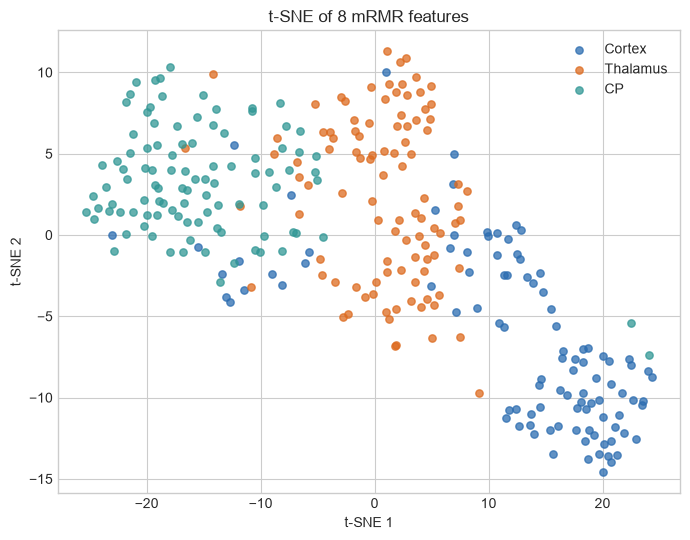

In [17]:
selected_scaled = StandardScaler().fit_transform(X[selected_features])
embedding = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42,
).fit_transform(selected_scaled)

figure, ax = plt.subplots(figsize=(7, 5.5))
for region in TARGET_REGIONS:
    mask = y == region
    ax.scatter(
        embedding[mask, 0], embedding[mask, 1],
        s=28, alpha=0.75, label=region, color=REGION_COLORS[region]
    )
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title(f"t-SNE of {N_SELECTED} mRMR features")
ax.legend()
figure.tight_layout()

For a downstream task, we use a classifier (logistic regression) on the train/test split dataset. 
We add one feature at a time, evaluating every
$k=1,2,\ldots,22$ from the relevance-only and mRMR rankings.

- **relevance only:** useful features can still repeat the same information;
- **mRMR:** each added feature is also penalized for redundancy;


In [18]:
train_index, test_index = train_test_split(
    np.arange(len(X)), test_size=0.20, stratify=y, random_state=42
)

def test_accuracy(columns):
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    model.fit(X.iloc[train_index][columns], y.iloc[train_index])
    prediction = model.predict(X.iloc[test_index][columns])
    return accuracy_score(y.iloc[test_index], prediction)

k_values = list(range(1, len(feature_names) + 1))
relevance_order = mi_relevance.index.tolist()
performance_rows = []
for k in k_values:
    performance_rows.append({
        "method": "relevance only",
        "k": k,
        "test accuracy": test_accuracy(relevance_order[:k]),
    })
    performance_rows.append({
        "method": "mRMR",
        "k": k,
        "test accuracy": test_accuracy(mrmr_order[:k]),
    })

performance_rows.append({
    "method": "all 22 features",
    "k": len(feature_names),
    "test accuracy": test_accuracy(feature_names),
})
performance = pd.DataFrame(performance_rows)
performance.pivot(index="k", columns="method", values="test accuracy")

method,all 22 features,mRMR,relevance only
k,,,
1,NaN,0.617,0.617
2,NaN,0.867,0.633
3,NaN,0.867,0.633
4,NaN,0.867,0.867
5,NaN,0.883,0.867
6,NaN,0.900,0.883
7,NaN,0.900,0.900
8,NaN,0.900,0.900
9,NaN,0.917,0.900


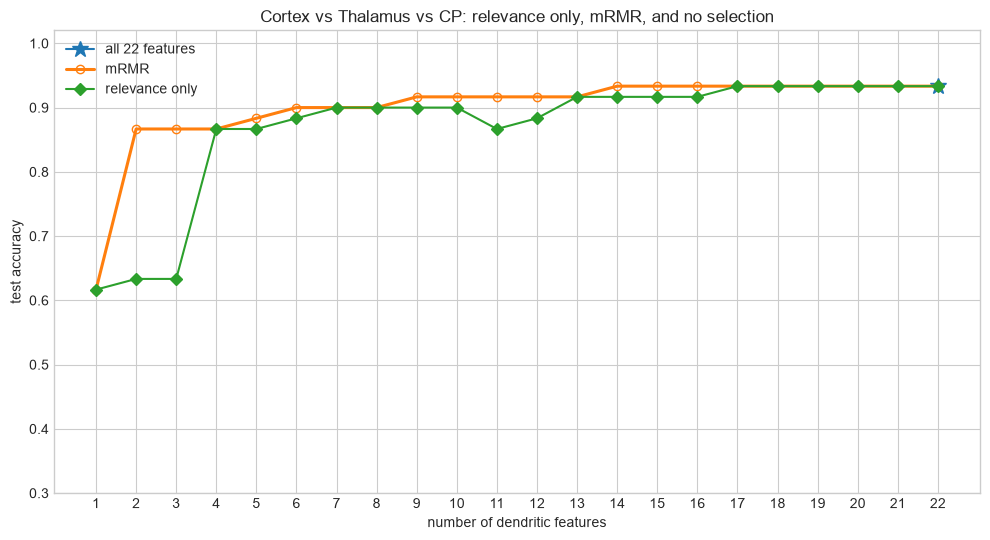

In [19]:
styles = {
    "relevance only": {"marker": "D", "color": "#2ca02c"},
    "mRMR": {
        "marker": "o", "markerfacecolor": "none",
        "linewidth": 2.2, "color": "#ff7f0e",
    },
    "all 22 features": {"marker": "*", "markersize": 12, "color": "#1f77b4"},
}
plt.figure(figsize=(10, 5.5))
for method, group in performance.groupby("method"):
    plt.plot(
        group["k"], group["test accuracy"],
        label=method, **styles[method]
    )
plt.ylim(0.30, 1.02)
plt.xlabel("number of dendritic features")
plt.ylabel("test accuracy")
plt.xticks(k_values)
plt.title(f"{' vs '.join(TARGET_REGIONS)}: relevance only, mRMR, and no selection")
plt.legend()
plt.tight_layout()

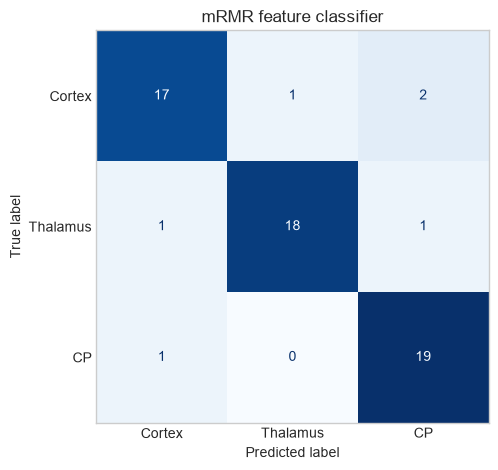

In [20]:
mrmr_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
mrmr_model.fit(X.iloc[train_index][selected_features], y.iloc[train_index])
mrmr_prediction = mrmr_model.predict(X.iloc[test_index][selected_features])

ConfusionMatrixDisplay.from_predictions(
    y.iloc[test_index], mrmr_prediction,
    labels=TARGET_REGIONS, cmap="Blues", colorbar=False
)
plt.title("mRMR feature classifier")
plt.grid(False)
plt.tight_layout()

---

## ✅✅✅ Basic mRMR workflow complete ✅✅✅

At this point you have completed the core workflow:

1. discretized continuous morphology into three states;
2. calculated mutual information for relevance and redundancy;
3. balanced relevance and redundancy with MID;
4. checked the result against the package `pymrmr`;
5. used the selected features in t-SNE and a classifier.

The extensions below ask how much the answer changes when we change the
discretization rule or the mRMR implementation.

# Extension 1 — Discretization sensitivity

Keep count-based MI and the MID objective fixed, but change how each
continuous morphology feature is discretized:

- **mean ± SD (3 bins):** count-based MI after $\mu\pm\sigma$ discretization in previous demo;
- **quantile 4-bin:** quartile boundaries (Q1, median, Q3), as in a boxplot,
  give approximately equal-frequency bins;
- **uniform 5-bin:** five equal-width intervals span each feature's range.

We first compare maximum-relevance rankings, then the final MID feature sets.
This isolates binning sensitivity without changing the MI estimator or
mixing in libraries that redefine relevance or redundancy.

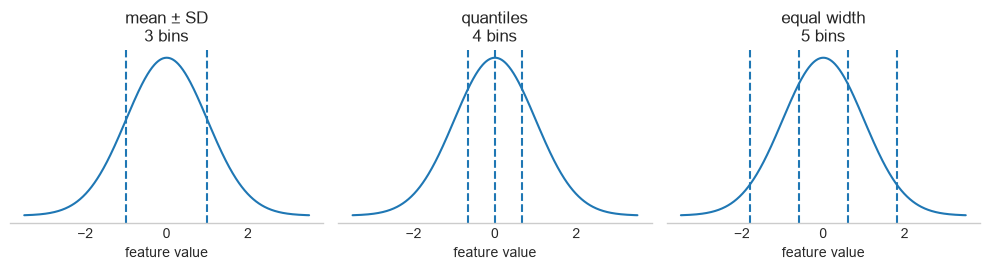

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plot_x = np.linspace(-3.5, 3.5, 500)
density = norm.pdf(plot_x)

fig, axes = plt.subplots(1, 3, figsize=(10, 2.8), sharey=True)

# 1) mean ± SD
ax = axes[0]
ax.plot(plot_x, density)
ax.axvline(-1, ls="--")
ax.axvline(1, ls="--")
ax.set_title("mean ± SD\n3 bins")

# 2) quantile 4-bin
ax = axes[1]
ax.plot(plot_x, density)
for q in [0.25, 0.5, 0.75]:
    ax.axvline(norm.ppf(q), ls="--")
ax.set_title("quantiles\n4 bins")

# 3) uniform 5-bin
ax = axes[2]
ax.plot(plot_x, density)
for cutoff in np.linspace(-3, 3, 6)[1:-1]:
    ax.axvline(cutoff, ls="--")
ax.set_title("equal width\n5 bins")

for ax in axes:
    ax.set_xlabel("feature value")
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.grid(False)
plt.tight_layout()
plt.show()

In [22]:
def discretize_quantiles(features, n_bins=4):
    '''Assign each feature to approximately equal-sized quantile bins.'''
    return pd.DataFrame({
        name: pd.qcut(features[name], n_bins, labels=False, duplicates="drop")
        .fillna(0).astype(int)
        for name in features
    })


def discretize_uniform(features, n_bins=5):
    '''Assign each feature to equal-width bins spanning its observed range.'''
    return pd.DataFrame({
        name: pd.cut(features[name], bins=n_bins, labels=False, duplicates="drop")
        .fillna(0).astype(int)
        for name in features
    })


X_quantile4 = discretize_quantiles(X, n_bins=4)
X_uniform5 = discretize_uniform(X, n_bins=5)
quantile4_relevance = relevance_scores(X_quantile4, y)
uniform5_relevance = relevance_scores(X_uniform5, y)


In [23]:
quantile4_order, _ = my_mRMR(X_quantile4, y, k=len(feature_names))
uniform5_order, _ = my_mRMR(X_uniform5, y, k=len(feature_names))

binning_orders = {
    "mean ± SD (3 bins)": mrmr_order,
    "quantile 4-bin": quantile4_order,
    "uniform 5-bin": uniform5_order,
}
binning_sets = {
    name: order[:N_SELECTED]
    for name, order in binning_orders.items()
}
pd.DataFrame({name: pd.Series(features) for name, features in binning_sets.items()})

,mean ± SD (3 bins),quantile 4-bin,uniform 5-bin
0,number_of_branches,total_surface,max_euclidean_distance
1,max_path_distance,average_contraction,average_contraction
2,average_bifurcation_angle_remote,max_euclidean_distance,number_of_tips
3,overall_height,average_bifurcation_angle_remote,average_bifurcation_angle_remote
4,average_contraction,max_branch_order,max_branch_order
5,overall_depth,overall_height,overall_height
6,number_of_stems,number_of_branches,total_length
7,number_of_bifurcations,max_path_distance,average_bifurcation_angle_local


Jaccard similarity asks whether the first eight selected features are stable.


,mean ± SD (3 bins),quantile 4-bin,uniform 5-bin
mean ± SD (3 bins),1.000,0.455,0.231
quantile 4-bin,0.455,1.000,0.455
uniform 5-bin,0.231,0.455,1.000


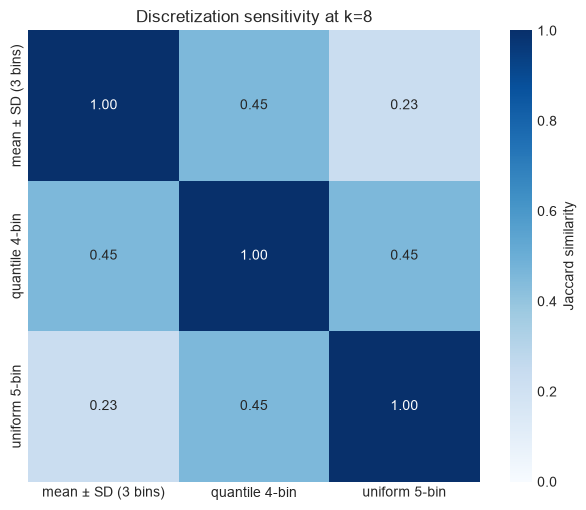

In [24]:
def jaccard(left, right):
    left, right = set(left), set(right)
    return len(left & right) / len(left | right)

def plot_jaccard(selection_sets, title):
    names = list(selection_sets)
    matrix = pd.DataFrame(
        [[jaccard(selection_sets[a], selection_sets[b]) for b in names] for a in names],
        index=names, columns=names,
    )
    plt.figure(figsize=(6.5, 5.2))
    sns.heatmap(
        matrix, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="Blues", square=True,
        cbar_kws={"label": "Jaccard similarity"},
    )
    plt.title(title)
    plt.tight_layout()
    return matrix

plot_jaccard(binning_sets, f"Discretization sensitivity at k={N_SELECTED}")

### Does discretization sensitivity affect the classifier?

The classifier asks a different question: as each ranked feature is added,
which binning rule's growing feature set predicts the held-out neurons better on
this dataset? We reuse the exact same split and logistic-regression pipeline
from the main workflow, so only the feature order changes.

Higher test accuracy is better for this demo. (not a general ranking of discretization rules)

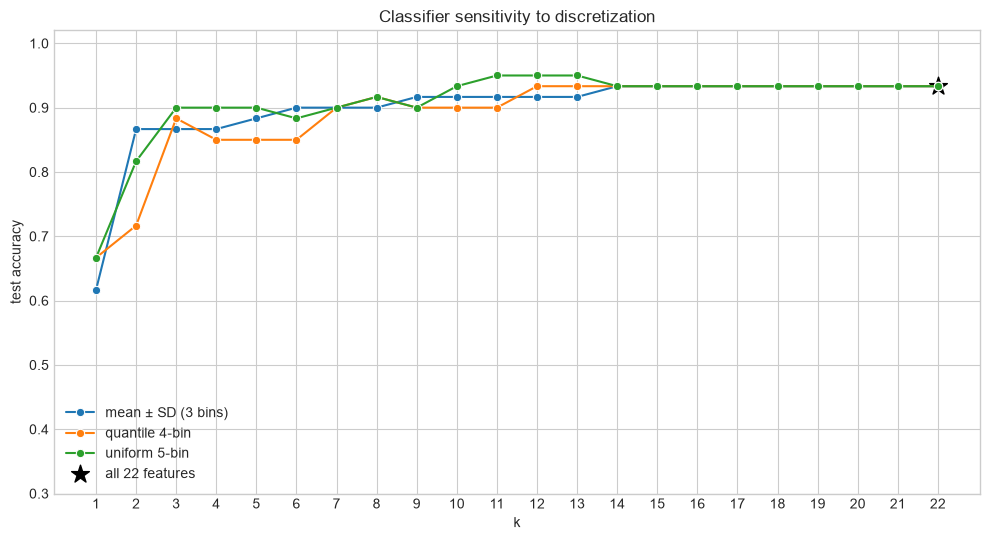

In [25]:
sensitivity_rows = []
for binning_method, order in binning_orders.items():
    for k in k_values:
        sensitivity_rows.append({
            "binning method": binning_method,
            "k": k,
            "test accuracy": test_accuracy(order[:k]),
        })
sensitivity_performance = pd.DataFrame(sensitivity_rows)

plt.figure(figsize=(10, 5.5))
ax = sns.lineplot(
    data=sensitivity_performance,
    x="k", y="test accuracy", hue="binning method", marker="o",
)
ax.scatter(
    len(feature_names), test_accuracy(feature_names),
    marker="*", s=180, color="black", label="all 22 features",
)
ax.set_ylim(0.30, 1.02)
ax.set_xticks(k_values)
ax.set_title("Classifier sensitivity to discretization")
ax.legend()
plt.tight_layout()

**Mean ± SD binning**\
This method defines bins relative to the population mean and standard deviation. It is useful for distinguishing unusually low, typical, and unusually high values. However, skewed distributions or outliers can shift the mean and standard deviation, leading to unbalanced bins.

**Equal-width/uniform binning**\
This method divides the observed numerical range into intervals of equal width. It preserves differences on the original measurement scale, so the same numerical distance corresponds to the same bin width. However, for skewed data or data with outliers, many observations may concentrate in only a few bins while others remain sparse.

**Quantile binning**\
This method chooses cut points so that each bin contains approximately the same number of observations. It emphasizes the relative rank or percentile of each observation rather than its absolute numerical distance from others. Balanced bin counts can stabilize count-based MI estimates, but large and small numerical differences may be treated similarly if they occupy similar ranks.

# Extension 2 — Existing libraries: mRMR is a framework

Now we intentionally broaden the definition:

- **my_mRMR / pymrmr** uses the discretized MI after mean ± SD three-state binning;
- **Feature-engine** uses sklearn continuous kNN MI for both relevance and
  redundancy;
- **mrmr-selection** use an ANOVA F-statistic for relevance and
  Pearson correlation for redundancy. (mRMR-style framework)


```python
from feature_engine.selection import MRMR  # usage: selected = MRMR(k=8).fit(X, y)
from mrmr import mrmr_classif  # usage: selected = mrmr_classif(X, y, K=8)
```

In [26]:
library_selections_by_k = {
    "my_mRMR (mean ± SD, 3 bins)": {},
    "Feature-engine": {},
    "mrmr-selection": {},
}
mrmr_selection_order = select_features(
    X, y, len(feature_names), method="mrmr_selection"
)

for k in k_values:
    library_selections_by_k["my_mRMR (mean ± SD, 3 bins)"][k] = mrmr_order[:k]
    library_selections_by_k["Feature-engine"][k] = select_features(
        X, y, k, method="feature_engine"
    )
    library_selections_by_k["mrmr-selection"][k] = (
        mrmr_selection_order[:k]
    )

library_sets = {
    name: selections[N_SELECTED]
    for name, selections in library_selections_by_k.items()
}
pd.DataFrame({name: pd.Series(features) for name, features in library_sets.items()})

,"my_mRMR (mean ± SD, 3 bins)",Feature-engine,mrmr-selection
0,number_of_branches,number_of_nodes,max_euclidean_distance
1,max_path_distance,overall_height,average_contraction
2,average_bifurcation_angle_remote,average_diameter,max_path_distance
3,overall_height,max_euclidean_distance,average_bifurcation_angle_remote
4,average_contraction,average_contraction,overall_depth
5,overall_depth,average_bifurcation_angle_local,number_of_tips
6,number_of_stems,average_bifurcation_angle_remote,overall_height
7,number_of_bifurcations,hausdorff_dimension,max_branch_order


,"my_mRMR (mean ± SD, 3 bins)",Feature-engine,mrmr-selection
"my_mRMR (mean ± SD, 3 bins)",1.000,0.231,0.455
Feature-engine,0.231,1.000,0.333
mrmr-selection,0.455,0.333,1.000


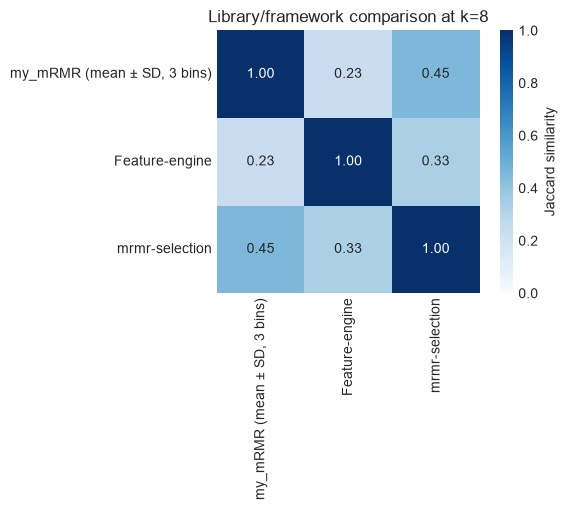

In [27]:
plot_jaccard(library_sets, f"Library/framework comparison at k={N_SELECTED}")

### Classifier sensitivity across mRMR implementations

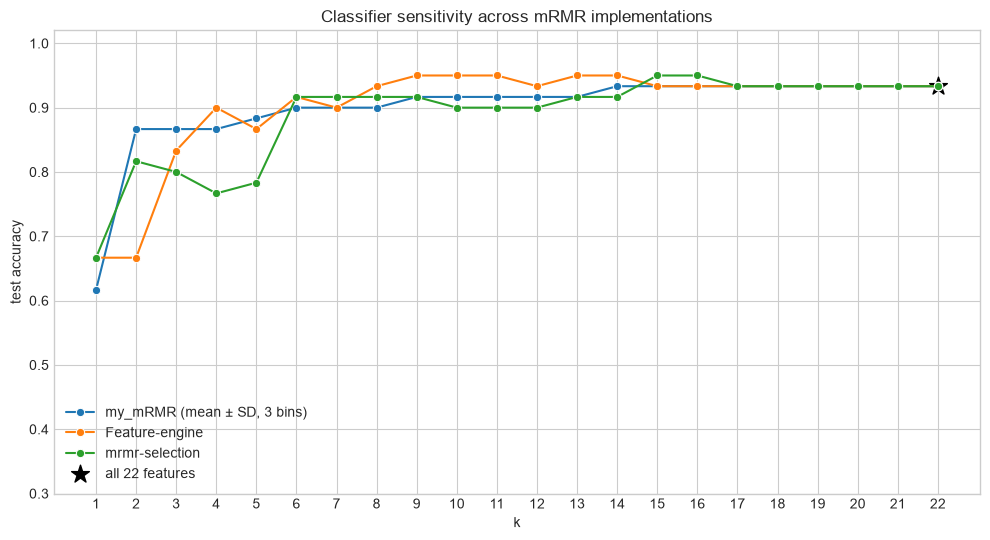

In [28]:
library_sensitivity_rows = []
for implementation, selections_by_k in library_selections_by_k.items():
    for k, features in selections_by_k.items():
        library_sensitivity_rows.append({
            "mRMR implementation": implementation,
            "k": k,
            "test accuracy": test_accuracy(features),
        })
library_sensitivity = pd.DataFrame(library_sensitivity_rows)

plt.figure(figsize=(10, 5.5))
ax = sns.lineplot(
    data=library_sensitivity,
    x="k", y="test accuracy", hue="mRMR implementation", marker="o",
)
ax.scatter(
    len(feature_names), test_accuracy(feature_names),
    marker="*", s=180, color="black", label="all 22 features",
)
ax.set_ylim(0.30, 1.02)
ax.set_xticks(k_values)
ax.set_title("Classifier sensitivity across mRMR implementations")
ax.legend()
plt.tight_layout()

**(mrmr-selection may not be the first choice)**